# Hidden Markov Models (forcasting weather)

## Importing,Cleaning and Defining Test/Train Split  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('seattle.csv',)

# Cleaning the data 

# Removing empty cells as this is weather data
df = df.dropna()

# Cleaning wrong date formats  
df['date'] = pd.to_datetime(df['date'],format= 'mixed')

# Defining Training and Testing set , (Cronologically as is the norm with weather data) , Used a 20:80 split
split = int(len(df)*0.8)
data = df[:split]
test = df[split:]

# Handel missing non positive values in Temp
Temp = data['temp_max']
Temp = Temp.dropna()
Temp = Temp[Temp > 0]

print(len(data['temp_max']))

1168


## ADF test for stationarity(For Tempreture)

In [2]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(Temp)

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -2.428618417466321
p-value: 0.13382143102112787
Critical Values:
   1%: -3.4360540638753405
   5%: -2.864058725215095
   10%: -2.568111031100567


#### Test Result
- The adf test reveals that that the data is not stationary at the given confidance interval therfore a transformation is required
- Remove the seasonality component given the context of weather data.
- Using a rolling mean of 30 days  $$ T' = T - 1/30 * \sum_{i=1}^n (T_{t-i}) $$ 
- As a result lost the first 30 data point
- Question to look into , what happens when there arent 30 datapoint to caluculate a mean then adjust from?

ADF Statistic: -9.650786002902793
p-value: 1.4366698234277682e-16
Critical Values:
   1%: -3.4361296862775528
   5%: -2.8640920853813365
   10%: -2.5681287981237304


<function matplotlib.pyplot.show(close=None, block=None)>

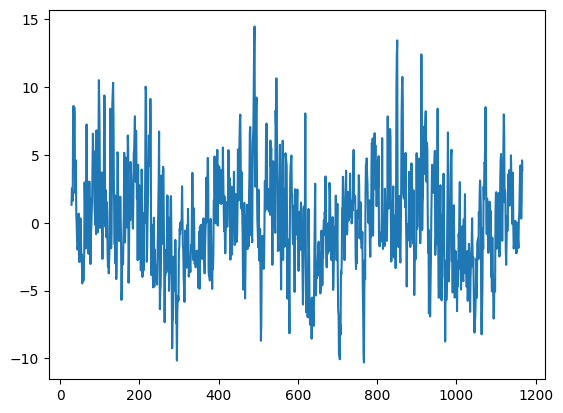

In [3]:
import numpy as np

TempTransformed = (data['temp_max']-data['temp_max'].rolling(30).mean()) #<- Number of elem
TempTransformed = TempTransformed.dropna() #<- Failed first time as the roling meand gave NaN for the first 30 data points

# Retesting for Stationarity 

result2 = adfuller(TempTransformed)

print("ADF Statistic:", result2[0])
print("p-value:", result2[1])
print("Critical Values:")
for key, value in result2[4].items():
    print(f"   {key}: {value}")
plt.plot(TempTransformed)
plt.show

#### Test Two Results 
- The data is Stationary significat to 1%> , furthermore for the pupose variation applying a first diffrance transformation.
- The trasnformation has form $$ x _t =  \delta T _t = T_t - T_{t-1} $$

ADF Statistic: -13.939284311623327
p-value: 4.9254342749910704e-26
Critical Values:
   1%: -3.4361812251221555
   5%: -2.864114820815637
   10%: -2.5681409066817795


<function matplotlib.pyplot.show(close=None, block=None)>

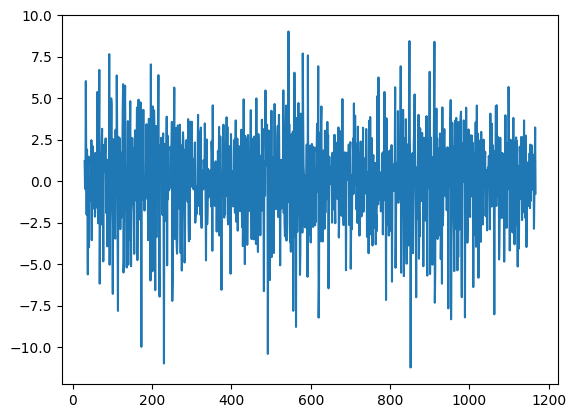

In [4]:
TempTransformed2 = (TempTransformed).diff()
TempTransformed2 = TempTransformed2.dropna()
# Retesing for  Stationarity

result3 = adfuller(TempTransformed2)

print("ADF Statistic:", result3[0])
print("p-value:", result3[1])
print("Critical Values:")
for key, value in result3[4].items():
    print(f"   {key}: {value}")
plt.plot(TempTransformed2)
plt.show

#### Further improvements on stationarity , no further transformation(except standardisation as a result of the model being a HMM) reqired.

- $$ z_t = (x_t -\mu)/\sigma $$
- Where x_t is the transformed data

ADF Statistic: -2.4286184174662355
p-value: 0.13382143102115113
Critical Values:
   1%: -3.4360540638753405
   5%: -2.864058725215095
   10%: -2.568111031100567


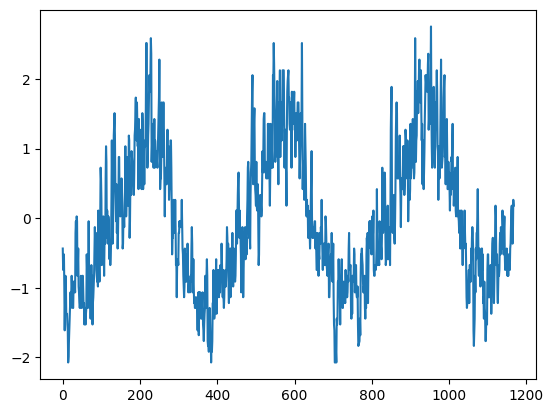

In [5]:
SampleMean = np.mean(Temp)
SampleVariance = np.std(Temp)

StdTemp = (Temp-SampleMean)/SampleVariance
StdTemp = StdTemp.dropna()

plt.plot(StdTemp)
plt.show
result3 = adfuller(StdTemp)
print("ADF Statistic:", result3[0])
print("p-value:", result3[1])
print("Critical Values:")
for key, value in result3[4].items():
    print(f"   {key}: {value}")

## Implemnting the Hidden Markov Model

- The number of states i have chosen is 3 folowing Hot, Cold, Normal regimes 
- Using the hmmlearn package

In [6]:
from hmmlearn.hmm import GaussianHMM

# Define the final time series after transformations
x = StdTemp.values.reshape(-1,1)
# Fitting the HMM

WeatherModel = GaussianHMM(n_components=3,covariance_type="full",n_iter=100)
WeatherModel.fit(x)

# Infering the hidden states and developing the transition matrix
States = WeatherModel.predict(x)
print(States)
print(WeatherModel.transmat_)

# Emission parameters
print(WeatherModel.means_)
print(WeatherModel.covars_)

mu = WeatherModel.means_
sigma = WeatherModel.covars_
 

[0 2 0 ... 0 2 0]
[[1.59975147e-01 1.44424827e-02 8.25582371e-01]
 [1.62344791e-02 9.83666600e-01 9.89206805e-05]
 [9.85493724e-01 1.01158514e-02 4.39042425e-03]]
[[-0.71102765]
 [ 0.95110801]
 [-0.72362732]]
[[[0.25242249]]

 [[0.40732578]]

 [[0.24978961]]]


### Developing path genarataion functions    

In [7]:
# Build function to undo transformations applied after next temp is predicted
# Cannot cleanly recover data
def UndoTrans(PredictedTemp,SampleMean,SampleVariance):
    # undo standardisation 
    PredictedTemp = PredictedTemp*SampleVariance + SampleMean
    # undo first diffrence

# Building a function that retuens the next state given the current state
def GetNextState(CurrentState):
    NextState = np.random.choice(range(WeatherModel.n_components),p=WeatherModel.transmat_[CurrentState])
    return NextState
# Bulid a path genarating function of n steps split into a function that genarates a series of states fist then using the distribution gained from training the HMM we genarate temprature values 
def TypeSimul(N,IntialState):
   Path = [IntialState]  
   for i in range(N):
       Path.append(GetNextState(Path[-1]))
   return Path

def Simul(N):
    Path = TypeSimul(N,1)
    TempTrans = [np.random.normal(mu[i], sigma[i]) for i in Path]
    for i in range(len(TempTrans)):
        TempTrans[i] = SampleMean + SampleVariance*TempTrans[i]
    return TempTrans

print(Simul(5))

[array([[20.89133836]]), array([[22.70423891]]), array([[24.95688251]]), array([[19.33640087]]), array([[26.51310215]]), array([[25.62969328]])]


## Analysis

The HMM was trained on the transformed maximum temperature series, so the hidden states should be interpreted as latent temperature regimes rather than the observed weather labels in the data. The three-state setup is a reasonable first model because it maps naturally to cold, normal, and hot periods, but it should still be checked against nearby alternatives rather than accepted only because it is easy to interpret.

A useful way to check this choice is to fit models with different numbers of hidden states and compare log likelihood, AIC, and BIC. The log likelihood will usually improve as states are added, so AIC/BIC are included to penalise models that become more complex without adding enough explanatory value.

### Checking the Validity of a Three State Model

The cell below compares one to six hidden states. If the three-state model has the lowest BIC, or is close to the lowest BIC while being easier to interpret, it supports keeping the cold/normal/hot regime structure. If four or more states are strongly preferred, the extra states may be capturing seasonal sub-regimes rather than genuinely different short-term weather dynamics.

In [8]:
import numpy as np
import pandas as pd

def hmm_parameter_count(n_states, n_features=1):
    start_params = n_states - 1
    transition_params = n_states * (n_states - 1)
    mean_params = n_states * n_features
    covariance_params = n_states * n_features
    return start_params + transition_params + mean_params + covariance_params

model_selection = []

for n_states in range(1, 7):
    candidate = GaussianHMM(
        n_components=n_states,
        covariance_type="full",
        n_iter=200,
        random_state=42,
    )
    candidate.fit(x)
    log_likelihood = candidate.score(x)
    n_params = hmm_parameter_count(n_states)
    model_selection.append({
        "states": n_states,
        "log_likelihood": log_likelihood,
        "AIC": 2 * n_params - 2 * log_likelihood,
        "BIC": np.log(len(x)) * n_params - 2 * log_likelihood,
    })

model_selection = pd.DataFrame(model_selection)
model_selection

,states,log_likelihood,AIC,BIC
0,1,-1650.225514,3304.451028,3314.568545
1,2,-1029.460741,2072.921483,2108.332790
2,3,-1029.235365,2086.470731,2157.293345
3,4,-704.056526,1454.113052,1570.464490
4,5,-702.991690,1473.983379,1645.981156
5,6,-616.764750,1327.529500,1565.291133


### Comparison Against the Test Set

For evaluation, the HMM is used as a one-step-ahead model. The current test observation is assigned to a hidden state, the transition matrix gives the expected next hidden state, and the next temperature prediction is calculated from the weighted average of the next-state emission means. This avoids judging the model from one random simulated path, which would make the error depend heavily on random sampling.

In [9]:
def regression_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    error = actual - predicted
    return {
        "MAE": np.mean(np.abs(error)),
        "RMSE": np.sqrt(np.mean(error ** 2)),
        "Bias": np.mean(predicted - actual),
    }

test_temp = test["temp_max"].dropna()
test_temp = test_temp[test_temp > 0]
test_std = ((test_temp - SampleMean) / SampleVariance).values.reshape(-1, 1)

current_states = WeatherModel.predict(test_std[:-1])
expected_next_std = np.array([
    WeatherModel.transmat_[state] @ WeatherModel.means_.ravel()
    for state in current_states
])

hmm_predictions = SampleMean + SampleVariance * expected_next_std
persistence_predictions = test_temp.iloc[:-1].values
actual_next_temp = test_temp.iloc[1:].values

pd.DataFrame([
    {"model": "HMM", **regression_metrics(actual_next_temp, hmm_predictions)},
    {"model": "Persistence baseline", **regression_metrics(actual_next_temp, persistence_predictions)},
])

,model,MAE,RMSE,Bias
0,HMM,3.934582,4.816061,-0.628392
1,Persistence baseline,2.353082,3.061722,0.028425


### Compare with the State Dependent Gaussian Model

The supervised state-dependent Gaussian model uses the observed weather type as the state space, so it has a different interpretation from the HMM. It is not trying to discover hidden regimes; it uses known labels such as rain, sun, fog, drizzle, and snow. This gives it more direct information, but it also means it depends on knowing the current weather type at prediction time.

The comparison below uses the same one-step-ahead structure as the HMM. From the current observed weather type, the weather-type transition matrix gives the expected next weather type, and the next temperature is predicted as the transition-weighted average of the emission means for each weather type.

In [10]:
weather_states = sorted(data["weather"].unique())
state_to_index = {state: i for i, state in enumerate(weather_states)}

weather_transition = np.zeros((len(weather_states), len(weather_states)))
train_weather = data["weather"].reset_index(drop=True)

for current_state in weather_states:
    current_index = state_to_index[current_state]
    transition_from_state = train_weather[:-1] == current_state
    total_transitions = transition_from_state.sum()

    if total_transitions == 0:
        weather_transition[current_index, current_index] = 1
        continue

    next_weather = train_weather.shift(-1)[:-1][transition_from_state]
    for next_state in weather_states:
        next_index = state_to_index[next_state]
        weather_transition[current_index, next_index] = (next_weather == next_state).sum() / total_transitions

weather_emission_means = data.groupby("weather")["temp_max"].mean().reindex(weather_states).values
test_weather = test["weather"].reset_index(drop=True)
test_temp_supervised = test["temp_max"].reset_index(drop=True)

supervised_predictions = []
supervised_actual = []

for i in range(len(test_weather) - 1):
    current_weather = test_weather.iloc[i]
    if current_weather not in state_to_index:
        continue

    transition_probs = weather_transition[state_to_index[current_weather]]
    supervised_predictions.append(transition_probs @ weather_emission_means)
    supervised_actual.append(test_temp_supervised.iloc[i + 1])

pd.DataFrame([
    {"model": "HMM", **regression_metrics(actual_next_temp, hmm_predictions)},
    {"model": "Supervised weather-type Gaussian", **regression_metrics(supervised_actual, supervised_predictions)},
    {"model": "Persistence baseline", **regression_metrics(actual_next_temp, persistence_predictions)},
])

,model,MAE,RMSE,Bias
0,HMM,3.934582,4.816061,-0.628392
1,Supervised weather-type Gaussian,5.924243,7.325813,-2.643988
2,Persistence baseline,2.353082,3.061722,0.028425


### Overall Interpretation

The HMM is useful because it can learn latent temperature regimes without being given the weather labels. Its transition matrix also gives interpretable regime persistence: high diagonal values mean that once the process enters a cold, normal, or hot state, it tends to remain there for at least another day.

The supervised state-dependent Gaussian model is easier to explain because the states are observed weather categories. However, it uses extra information that the HMM does not use. If the supervised model has lower MAE/RMSE, this suggests that the observed weather label contains useful predictive information about temperature. If the HMM performs similarly, then most of the short-term structure is already being captured by the temperature series alone.

A limitation of both models is that they use simple Gaussian emissions and first-order Markov transitions. Seattle temperature has seasonal structure, so future improvements should model seasonality explicitly, for example by adding month/season features, fitting separate seasonal HMMs, or comparing against time-series baselines such as ARIMA or exponential smoothing.